In [5]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os
from scipy.optimize import curve_fit

Import my colony counts recorded in Excel

In [6]:
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Results 16 October.xlsx"
data = pd.read_excel(path)

#Set dose levels and used plating numbers
Dose_levels = [0, 2, 5, 8]
Plating_numbers = [500, 1000, 3000, 6000]

#print(data)

In [7]:
def Perform_LQ_fit(doses, survival):
    #Generate LQ fit

    #inputs:
    #doses = list of used dose levels
    #survival = dictionary with survival data per dose level

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations
    
    def LQ_function(d, a, b):
        exponent = -(a*d + b*(np.square(d)))
        return exponent

    xvals = np.array(doses)
    yvals = np.array(list(survival.values()))
    yvals = np.log(yvals)

    p0 = (0.1, 0.1)

    popt, pcov = curve_fit(LQ_function, xvals, yvals, p0=p0, bounds=(0,1))
    
    return popt, LQ_function

In [25]:
def Parse_data(doselevels, platingnumbers, input):
    #Split colony counting data into cell survival per dose level

    #inputs:
    #doselevels = list of the used dose levels
    #platingnumbers = list of the plating numbers for each dose level
    #input = dataframe with the dose and count for each sample

    output_survival = {}
    output_std = {}

    output_df = pd.DataFrame(columns=['Dose', 'Count', 'PE'])
    
    for i in range(len(doselevels)):
        dose = doselevels[i]
        plating_number = platingnumbers[i]

        #Isolate data from this dose level
        dose_level_data = input[input['Dose'] == dose]

        #Write to dataframe
        for row in dose_level_data.itertuples():
            count = row.Count
            plating_eff = count/plating_number
            newrow = pd.DataFrame([{'Dose': dose, 'Count':count, 'PE': plating_eff}])
            output_df = pd.concat([output_df, newrow], ignore_index=True)

        #Find average colony count
        average_count = dose_level_data['Count'].mean()

        #Calculate survival
        if i == 0:
            #If we're on the control sample, store value
            control_survival = average_count/plating_number
        survival = (average_count/plating_number)/control_survival

        #Write survival to dictionary
        output_survival[f"{dose} Gy"] = survival
        output_std[f"{dose} Gy"] = (dose_level_data['Count'].std()/plating_number)/control_survival


    return output_survival, output_std, output_df


Plot data and generate LQ curve for X-rays

{'0 Gy': 1.0, '2 Gy': 0.7916666666666666, '5 Gy': 0.14583333333333334, '8 Gy': 0.004629629629629629}
{'0 Gy': 0.6468406123441677, '2 Gy': 0.6005639710583156, '5 Gy': 0.1434998494428599, '8 Gy': 0.0020046884346862004}
   Dose Count        PE
0     0    39  0.078000
1     0     8  0.016000
2     0    25  0.050000
3     2    69  0.069000
4     2    33  0.033000
5     2    12  0.012000
6     5     4  0.001333
7     5    44  0.014667
8     5    15  0.005000
9     8     1  0.000167
10    8     2  0.000333
11    8     1  0.000167


C:\Users\bhaan\AppData\Local\Temp\ipykernel_18180\3751609915.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = pd.concat([output_df, newrow], ignore_index=True)


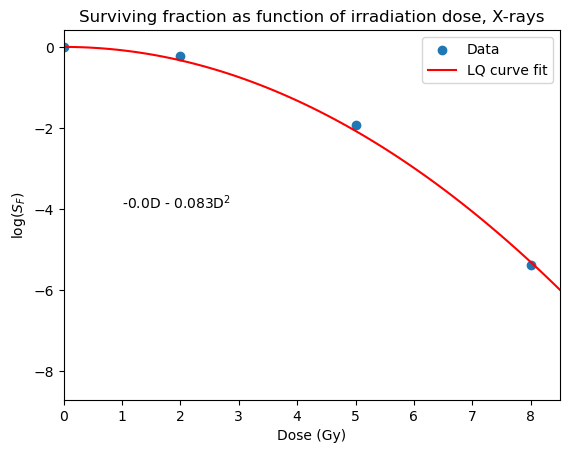

In [26]:
#Filter out X-ray results
X_ray_samples = data[data['Rad'] == 'X']

#Split per dose level
X_ray_survival, X_ray_survival_std, X_ray_df = Parse_data(Dose_levels, Plating_numbers, X_ray_samples)

print(X_ray_survival)
print(X_ray_survival_std)
print(X_ray_df)

#Generate LQ fit plot
params_x, LQ_func = Perform_LQ_fit(Dose_levels, X_ray_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(X_ray_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), label='LQ curve fit', color = 'r')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, X-rays')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_x[0],3)}D - {round(params_x[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()
    

Plot data and generate LQ curve for protons low LET

{'0 Gy': 1.0, '2 Gy': 0.39189189189189183, '5 Gy': 0.08502252252252251, '8 Gy': 0.003378378378378378}
{'0 Gy': 0.16163342856629304, '2 Gy': 0.17476374535645356, '5 Gy': 0.03463181151955356, '8 Gy': 0.001462880749635876}
   Dose Count        PE
0     0   112  0.224000
1     0    81  0.162000
2     0   103  0.206000
3     2    40  0.040000
4     2   108  0.108000
5     2    84  0.084000
6     5    74  0.024667
7     5    38  0.012667
8     5    39  0.013000
9     8     3  0.000500
10    8     6  0.001000
11    8     3  0.000500


C:\Users\bhaan\AppData\Local\Temp\ipykernel_18180\3751609915.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = pd.concat([output_df, newrow], ignore_index=True)


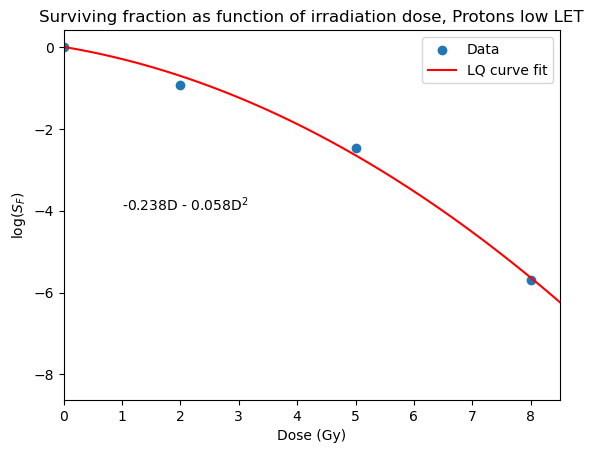

In [28]:
#Filter out proton low LET results
Proton_low_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton H')]

#Split per dose level
Proton_low_survival, Proton_low_survival_std, Proton_low_df = Parse_data(Dose_levels, Plating_numbers, Proton_low_samples)

print(Proton_low_survival)
print(Proton_low_survival_std)
print(Proton_low_df)

#Generate LQ fit plot
params_lp, LQ_func = Perform_LQ_fit(Dose_levels, Proton_low_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(Proton_low_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_lp[0], params_lp[1]), label='LQ curve fit', color='r')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, Protons low LET')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_lp[0],3)}D - {round(params_lp[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()

Plot data and generate LQ curve for protons high LET

{'0 Gy': 1.0, '2 Gy': 0.20270270270270271, '5 Gy': 0.04842342342342343, '8 Gy': 0.015484234234234232}
{'0 Gy': 0.16163342856629304, '2 Gy': 0.11183146870294211, '5 Gy': 0.0795235634201016, '8 Gy': 0.02390864160536278}
   Dose Count        PE
0     0   112  0.224000
1     0    81  0.162000
2     0   103  0.206000
3     2    17  0.017000
4     2    42  0.042000
5     2    61  0.061000
6     5     0  0.000000
7     5    83  0.027667
8     5     3  0.001000
9     8     1  0.000167
10    8     3  0.000500
11    8    51  0.008500


C:\Users\bhaan\AppData\Local\Temp\ipykernel_18180\3751609915.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = pd.concat([output_df, newrow], ignore_index=True)


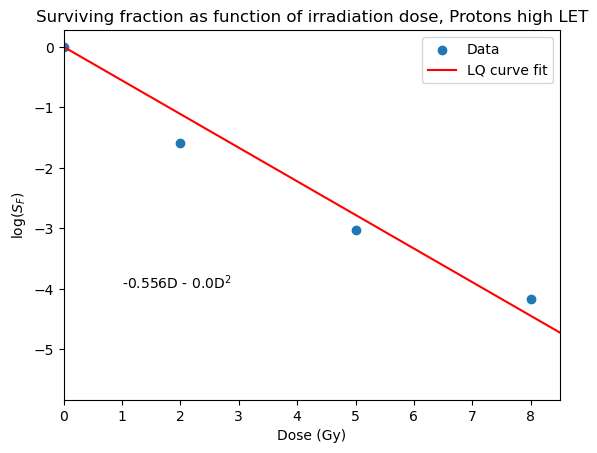

In [29]:
#Filter out proton high LET results
Proton_high_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton L')]

#Split per dose level
Proton_high_survival, Proton_high_survival_std, Proton_high_df = Parse_data(Dose_levels, Plating_numbers, Proton_high_samples)

print(Proton_high_survival)
print(Proton_high_survival_std)
print(Proton_high_df)

#Generate LQ fit plot
params_hp, LQ_func = Perform_LQ_fit(Dose_levels, Proton_high_survival)

#Plot data and curve fit
plt.scatter(Dose_levels, np.log(np.array(list(Proton_high_survival.values()))), label='Data')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_hp[0], params_hp[1]), label='LQ curve fit', color='r')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose, Protons high LET')
#plt.yscale('log')
plt.text(1, -4, f"-{round(params_hp[0],3)}D - {round(params_hp[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.legend()

Plot all data together

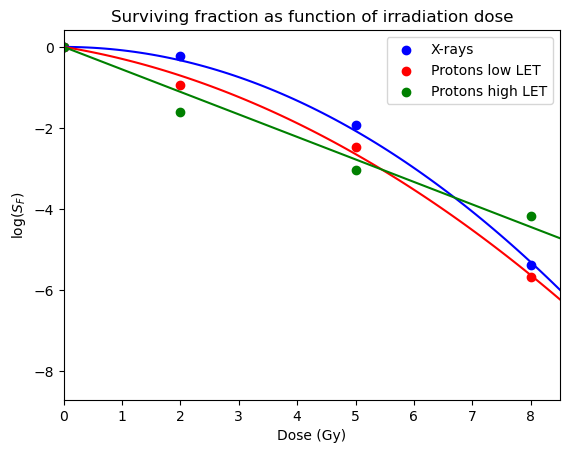

In [19]:
plt.scatter(Dose_levels, np.log(np.array(list(X_ray_survival.values()))), color='b', label='X-rays')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color = 'b')

plt.scatter(Dose_levels, np.log(np.array(list(Proton_low_survival.values()))), label='Protons low LET', color='r')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_lp[0], params_lp[1]), color='r')

plt.scatter(Dose_levels, np.log(np.array(list(Proton_high_survival.values()))), label='Protons high LET', color='g')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_hp[0], params_hp[1]), color='g')

plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction as function of irradiation dose')
plt.xlim([0, 8.5])
plt.legend()